# 08 - Association Rules (PuneBite Analyzer)

**Objective:** discover common cuisine combinations and relationships between amenities/restaurant types using Apriori and compare its frequent itemsets with FP-Growth.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** rule explanations, charts, and `data/processed/association_rules.csv`
**Syllabus link:** Unit VI, Lab 8 (frequent itemsets and association-rule mining).

Each restaurant is one transaction. Support is the share of all restaurants containing a pattern; confidence is the share of transactions containing the antecedent that also contain the consequent; lift compares that confidence with the consequent's base rate (lift > 1 indicates a positive association, not causation).

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sns.set_theme(style="whitegrid")
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "restaurants_clean.csv")
print(f"Loaded {len(df):,} restaurants")

def pipe_items(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split("|") if item.strip()]

cuisine_transactions = [pipe_items(value) for value in df["cuisines"]]
amenity_transactions = []
for amenities, establishment_type in zip(df["amenities"], df["establishment_type"]):
    items = pipe_items(amenities)
    if pd.notna(establishment_type) and str(establishment_type).strip():
        items.append("type: " + str(establishment_type).strip())
    amenity_transactions.append(items)
print(f"Cuisine transactions: {len(cuisine_transactions):,}; amenity + type transactions: {len(amenity_transactions):,}")
print("Median transaction lengths:", pd.Series([len(x) for x in cuisine_transactions]).median(), "cuisines;", pd.Series([len(x) for x in amenity_transactions]).median(), "amenities/types")

Loaded 12,134 restaurants
Cuisine transactions: 12,134; amenity + type transactions: 12,134
Median transaction lengths: 2.0 cuisines; 4.0 amenities/types


In [2]:
MIN_SUPPORT = 0.015
MIN_LIFT = 1.2
MIN_CONFIDENCE = 0.5
MAX_ITEMSET_LENGTH = 3

def mine_basket(name, transactions):
    encoder = TransactionEncoder()
    encoded = encoder.fit(transactions).transform(transactions)
    basket = pd.DataFrame(encoded, columns=encoder.columns_)
    started = time.perf_counter()
    apriori_sets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_ITEMSET_LENGTH)
    apriori_seconds = time.perf_counter() - started
    started = time.perf_counter()
    fp_sets = fpgrowth(basket, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_ITEMSET_LENGTH)
    fpgrowth_seconds = time.perf_counter() - started
    apriori_keys = set(apriori_sets["itemsets"])
    fp_keys = set(fp_sets["itemsets"])
    print(f"{name}: {basket.shape[0]:,} transactions, {basket.shape[1]:,} unique items")
    print(f"Apriori: {len(apriori_sets):,} itemsets / {apriori_seconds:.2f}s; FP-Growth: {len(fp_sets):,} itemsets / {fpgrowth_seconds:.2f}s; same itemsets: {apriori_keys == fp_keys}")
    if apriori_keys != fp_keys:
        raise AssertionError(f"Apriori and FP-Growth produced different frequent itemsets for {name}")
    rules = association_rules(apriori_sets, metric="lift", min_threshold=MIN_LIFT)
    rules = rules.loc[rules["confidence"] >= MIN_CONFIDENCE].copy()
    rules["basket"] = name
    rules["antecedents_text"] = rules["antecedents"].apply(lambda items: ", ".join(sorted(items)))
    rules["consequents_text"] = rules["consequents"].apply(lambda items: ", ".join(sorted(items)))
    rules["plain_english"] = rules.apply(lambda r: f"When a transaction contains {r['antecedents_text']}, {r['consequents_text']} also appears in {r['confidence']:.0%} of those transactions (lift {r['lift']:.2f}).", axis=1)
    return apriori_sets, rules, {"basket": name, "transactions": len(transactions), "unique_items": basket.shape[1], "apriori_itemsets": len(apriori_sets), "apriori_seconds": apriori_seconds, "fpgrowth_seconds": fpgrowth_seconds, "rules_after_filters": len(rules)}

cuisine_itemsets, cuisine_rules, cuisine_benchmark = mine_basket("cuisines", cuisine_transactions)
amenity_itemsets, amenity_rules, amenity_benchmark = mine_basket("amenities_and_type", amenity_transactions)
benchmark = pd.DataFrame([cuisine_benchmark, amenity_benchmark])
display(benchmark)

cuisines: 12,134 transactions, 99 unique items
Apriori: 58 itemsets / 0.14s; FP-Growth: 58 itemsets / 0.14s; same itemsets: True
amenities_and_type: 12,134 transactions, 167 unique items
Apriori: 254 itemsets / 0.08s; FP-Growth: 254 itemsets / 0.26s; same itemsets: True


,basket,transactions,unique_items,apriori_itemsets,apriori_seconds,fpgrowth_seconds,rules_after_filters
0,cuisines,12134,99,58,0.139006,0.136873,26
1,amenities_and_type,12134,167,254,0.081862,0.257810,223


,basket,antecedents_text,consequents_text,support,confidence,lift,plain_english
140,amenities_and_type,nightlife,"full_bar_available, smoking_are",0.0180,0.887,13.936,"When a transaction contains nightlife, full_ba..."
134,amenities_and_type,live_music,"full_bar_available, smoking_are",0.0170,0.795,12.501,"When a transaction contains live_music, full_b..."
29,amenities_and_type,type: Delivery,delivery_only,0.0746,1.000,12.432,"When a transaction contains type: Delivery, de..."
28,amenities_and_type,delivery_only,type: Delivery,0.0746,0.927,12.432,"When a transaction contains delivery_only, typ..."
104,amenities_and_type,"type: Casual Dining, Bar","full_bar_available, home_delivery",0.0169,0.653,11.736,When a transaction contains type: Casual Dinin...
30,amenities_and_type,type: Bakery,desserts_and_bakes,0.0209,0.981,11.610,"When a transaction contains type: Bakery, dess..."
137,amenities_and_type,live_sports_screening,"full_bar_available, smoking_are",0.0180,0.736,11.576,When a transaction contains live_sports_screen...
31,amenities_and_type,type: Dessert Parlor,desserts_and_bakes,0.0198,0.976,11.549,When a transaction contains type: Dessert Parl...
37,amenities_and_type,nightlife,full_bar_available,0.0204,1.000,10.729,"When a transaction contains nightlife, full_ba..."
112,amenities_and_type,"indoor_seating, nightlife",full_bar_available,0.0193,1.000,10.729,"When a transaction contains indoor_seating, ni..."


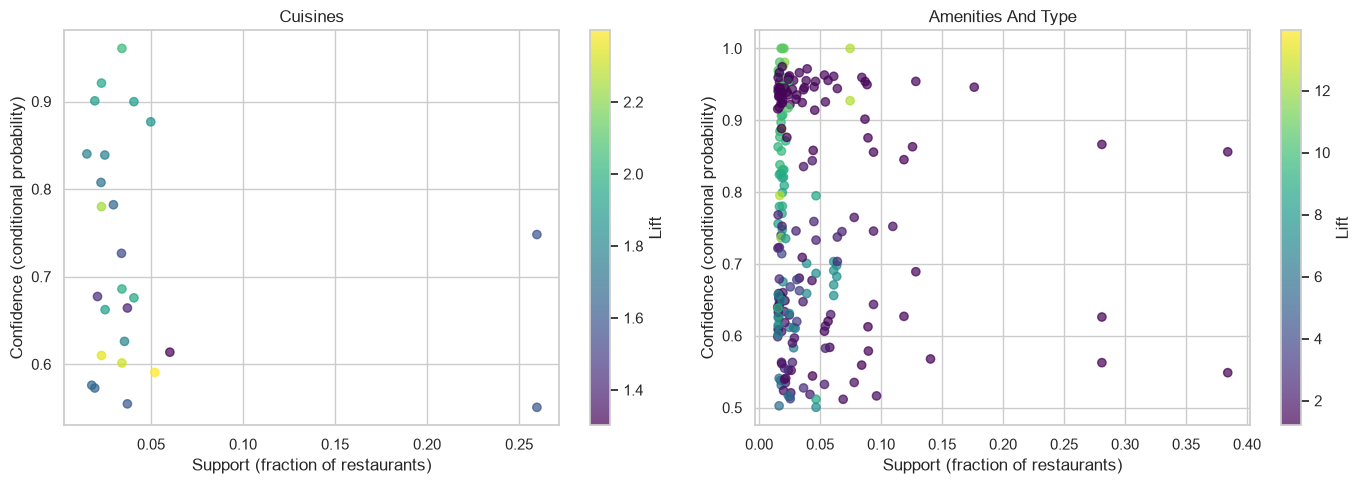

The strongest-lift amenities_and_type pattern is 'nightlife' -> 'full_bar_available, smoking_are': support 1.8%, confidence 88.7%, lift 13.94.
Saved 249 filtered association rules to A:\DSML\PuneBite\data\processed\association_rules.csv


In [3]:
all_rules = pd.concat([cuisine_rules, amenity_rules], ignore_index=True)
rule_columns = ["basket", "antecedents_text", "consequents_text", "support", "confidence", "lift", "plain_english"]
if all_rules.empty:
    print("No rules met both lift >= 1.2 and confidence >= 0.5. Consider a lower support threshold only if justified.")
else:
    display(all_rules.sort_values(["lift", "confidence"], ascending=False)[rule_columns].head(15).round({"support": 4, "confidence": 3, "lift": 3}))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for axis, basket_name in zip(axes, ["cuisines", "amenities_and_type"]):
        subset = all_rules.loc[all_rules["basket"] == basket_name]
        if not subset.empty:
            points = axis.scatter(subset["support"], subset["confidence"], c=subset["lift"], cmap="viridis", alpha=0.7)
            axis.set_title(basket_name.replace("_", " ").title())
            axis.set_xlabel("Support (fraction of restaurants)")
            axis.set_ylabel("Confidence (conditional probability)")
            fig.colorbar(points, ax=axis, label="Lift")
        else:
            axis.set_title(f"{basket_name}: no rules passed filters")
    plt.tight_layout()
    plt.show()

def explain_top_rule(rules):
    if rules.empty:
        return "No rule passed both thresholds."
    best = rules.sort_values(["lift", "confidence"], ascending=False).iloc[0]
    return f"The strongest-lift {best['basket']} pattern is '{best['antecedents_text']}' -> '{best['consequents_text']}': support {best['support']:.1%}, confidence {best['confidence']:.1%}, lift {best['lift']:.2f}."

print(explain_top_rule(all_rules))
output = all_rules[rule_columns].copy()
output_path = PROJECT_ROOT / "data" / "processed" / "association_rules.csv"
output.to_csv(output_path, index=False)
print(f"Saved {len(output):,} filtered association rules to {output_path}")

## Summary and findings

Apriori and FP-Growth are checked for identical frequent itemsets at the same minimum support, and their runtimes are recorded. Rule results are descriptive co-occurrences in this scraped restaurant listing dataset; they do not imply that one cuisine or amenity causes another.

In [4]:
print(f"Support threshold={MIN_SUPPORT:.1%}; report rules require lift >= {MIN_LIFT:.1f} and confidence >= {MIN_CONFIDENCE:.0%}; itemsets capped at length {MAX_ITEMSET_LENGTH}.")
print(benchmark.to_string(index=False))
print(f"Filtered rules: cuisines={len(cuisine_rules):,}; amenities + type={len(amenity_rules):,}; total={len(all_rules):,}.")
print("Interpretation caution: minimum support excludes rare combinations; confidence can be high for common consequents, so read it together with support and lift.")

Support threshold=1.5%; report rules require lift >= 1.2 and confidence >= 50%; itemsets capped at length 3.
            basket  transactions  unique_items  apriori_itemsets  apriori_seconds  fpgrowth_seconds  rules_after_filters
          cuisines         12134            99                58         0.139006          0.136873                   26
amenities_and_type         12134           167               254         0.081862          0.257810                  223
Filtered rules: cuisines=26; amenities + type=223; total=249.
Interpretation caution: minimum support excludes rare combinations; confidence can be high for common consequents, so read it together with support and lift.
